# Mean number of wildtype mosquitoes per household under the 4 single release scenarios for a male only release
## Abby Barlow, The University of Bath
Uses 'SSA_relm_com_fem_switch.jl' for the stochastic simulation of the community scale releases and 'SSA_relm_hhold_fem_switch.jl' for household scale releases which are called in 'Single_release_sep_file.jl'.

To use the already produced results see 'Initial_release_experiments.csv' for the required zip file names.

Import libraries

In [1]:
### importing the required libraries
using CSV
using DataFrames
using Statistics
using Plots
using Tar
using CodecZlib

Import scripts

In [2]:
module Read
    include("Read_data_files.jl")
end

module Check
    include("Check_files_exist.jl")
end

Main.Check

### Key simulation parameters

JOB_ID defines the job run from the HPC and is used to identify each set of results. These are detailed in 'Initial_release_experiments.csv'.

gamma, rho, tau and alpha are the mosquito dispersal parameters.

num_simulations defines the number of simulation runs of the SSA for each result.

rel_type defines the release scale. 'relhhold' is for household scale releases and 'relcom' is for community scale releases.

In [3]:
### change this to the job id for the experiment you want to analyze
## or the name you want to give the folder where all the extracted data files will be stored
JOB_ID = 67133121
### make sure to write dispersal parameters as floats to keep file name consistent ###

## vary these for different dispersal scenarios
gamma = 0.33    # dispersal rate from release site to household
rho = 0.33      # rate visit the households
tau = 0.33      # rate leave the households
alpha = 0.1     # dispersal rate of females moving from household directly to another household

num_simulations = 100  # number of realisations of SSA to run, 10,000 is a good number for the paper
rel_type = "relcom"  # scale of release

"relcom"

Extracts zip files

In [4]:
# # Define the file path
# file_path = "Initial_paper_results\\sim_results_$(JOB_ID).tar.gz" #

# # Extract the .tar.gz file
# function extract_tar_gz(file_path::String, dest_dir::String)
#     open(file_path) do io
#         tar_io = GzipDecompressorStream(io)
#         Tar.extract(tar_io, dest_dir)
#     end
# end

# # Define the destination directory
# dest_dir =  joinpath("Initial_paper_results","$(JOB_ID)")

# # Extract the files
# extract_tar_gz(file_path, dest_dir)

# println("Extraction complete. Files are extracted to $dest_dir.")

Parameter dictionary

In [5]:
fem_w0 = 0  # how many wildtypes and infected mosquitoes starting off with
male_w0 = 0
fem_m0 = 8
male_m0 = 8
# initialise disperser pool
m_free0 = 0 # no. of free wild-type
w_free0 = 0 # no. of free Wolbachia

phi = 0.85      # wolbachia fitness effect on birth rate
K = 30          # carrying capacity of mosquitoes per household
d = 12/100      # death rate of mosquitoes
k = 0.3         # larval density parameter
h = 0.19*100^k  # larval density parameter
b = 0.54        # per capita birth rate of mosquitoes (wildtypes)
H = 100         # number of households
u = 1           # vertical transmission probability
v = 1           # CI effect, proportion of non-viable offspring from infected male and wildtype female birth

rel_t = 150   # initial release time
delta_rel = 0 # time in days between releases, currently set to a single release inside the SSA code
## remember this is per household for the household releases so should use smaller release numbers
## currently set for community wide release
rel_size = 8*H # total number of Wolbachia-infected mosquitoes released into the community

t_start = 0    
t_end = 1000   # start time and end time (days) of simulation

result_length = length(t_start:t_end) # number of time points to store results
weeks = round(Int,result_length/7)    # number of weeks to store results

parameters = Dict(           # dictionary of parameters
    :fem_m0 => fem_m0,
    :male_m0 => male_m0,
    :fem_w0 => fem_w0,
    :male_w0 => male_w0,
    :m_free0 => m_free0,
    :w_free0 => w_free0,
    :rho => rho,
    :phi => phi,
    :b => b,
    :K => K,
    :d => d,
    :h => h,
    :k => k,
    :u => u,
    :v => v,
    :tau => tau,
    :H => H,
    :t_start => t_start,
    :t_end => t_end,
    :seed => 1234,
    :delta_rel => delta_rel,
    :rel_size => rel_size,
    :gamma => gamma,
    :alpha => alpha,
    :rel_t => rel_t
)

Dict{Symbol, Real} with 25 entries:
  :b        => 0.54
  :alpha    => 0.1
  :rel_size => 800
  :gamma    => 0.33
  :m_free0  => 0
  :rho      => 0.33
  :t_start  => 0
  :h        => 0.756404
  :rel_t    => 150
  :male_w0  => 0
  :fem_m0   => 8
  :K        => 30
  :phi      => 0.85
  :fem_w0   => 0
  :d        => 0.12
  :k        => 0.3
  :v        => 1
  :u        => 1
  :male_m0  => 8
  ⋮         => ⋮

Converts dispersal parameters to strings for saving figures and returns the sum of the wildtype mosquitoes over time for each household (summed over simulations) and the number of simulations used.

In [6]:
alpha_str, gamma_str, rho_str, tau_str = Read.str_convert(alpha, gamma, rho, tau)

sum_array, ct = Check.check_file_exist(alpha_str, gamma_str, rho_str, tau_str, H, rel_t, rel_size, rel_type, num_simulations, JOB_ID)

# Compute the mean array
# this gives the mean over all sims for each household
if ct > 0
    mean_array_h = sum_array ./ ct
    println("Mean array computed successfully.")
else
    println("No valid data files found.")
end

Mean array computed successfully.


Unpacks the pre-processed results.

In [10]:
mean_df = CSV.read(joinpath("../Initial_paper_results","mean_wild_hhold_male.csv"), DataFrame)
mean_array_015 = mean_df[!, :mean_array_015] # extract the mean values from the DataFrame
mean_array_033 = mean_df[!, :mean_array_033]
mean_array_2 = mean_df[!, :mean_array_2]
mean_array_h = mean_df[!, :mean_array_h]

143-element Vector{Float64}:
 16.0
 13.2821
 13.535800000000004
 13.659599999999998
 13.787499999999996
 13.9544
 13.986500000000001
 13.996399999999996
 14.041900000000005
 14.077100000000003
  ⋮
 14.146999999999998
 14.254000000000001
 14.1974
 14.114300000000004
 14.2422
 14.186299999999996
 14.185000000000008
 14.183099999999998
 14.263100000000003

Produces the figure for the mean number of wildtype mosquitoes in a household over time.

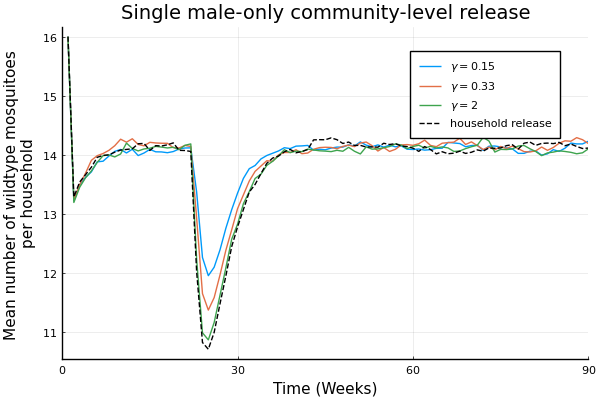

In [15]:
pyplot()  # using the pyplot backend for plotting

# gamma = 0.15
p = plot(mean(mean_array_015, dims=2), xlabel="Time (Weeks)", ylabel="Mean number of wildtype mosquitoes 
per household",
    titlefont=font(14), label="\$\\gamma=0.15\$")

# gamma = 0.33
plot!(p, mean(mean_array_033, dims=2), label="\$\\gamma=0.33\$")
# gamma = 2
plot!(p, mean(mean_array_2, dims=2), label="\$\\gamma=2\$")
# household release
plot!(p, mean(mean_array_h, dims=2), label="household release", linecolor=:black, linestyle=:dash)
# produces title
plot!(p, title="Single male-only community-level release", legend=:topleft)

# Set the x and y limits
plot!(p, xlim=(0, 90))
plot!(p, legend=(0.65,0.65))

# Save the plot
#savefig(p, "wild_per_house_alphas_$(gamma_str)_$(rho_str)_$(tau_str)_$(H)__$(rel_t)_$(rel_size)_$(rel_type).pdf")
# Display the plot

Saved the processed results to be reused.

In [12]:
# df = CSV.read("mean_wild_hhold_male.csv", DataFrame)

# # Extract columns as vectors
# mean_array_015 = df.mean_array_015
# mean_array_033 = df.mean_array_033
# mean_array_2   = df.mean_array_2
# mean_array_h   = df.mean_array_h

# # If you need them as arrays (for plotting or further calculations)
# mean_array_015 = collect(mean_array_015)
# mean_array_033 = collect(mean_array_033)
# mean_array_2   = collect(mean_array_2)
# mean_array_h   = collect(mean_array_h)